In [19]:
import numpy as np
import pathlib
from superstore_analysis.pipelines.inference_pipeline import ClusterInfer, ClassifyInfer
from superstore_analysis.datasets import DataLoader

# **1. Cluster Inference**

In [20]:
data = DataLoader().from_gdrive()

In [21]:
cluster_infer = ClusterInfer()
X_preproc = cluster_infer.infer(data)

2026-03-06 01:29:16.140 | INFO     | superstore_analysis.pipelines.feature_eng_pipeline:transform:15 - Start Feature Engineering...
2026-03-06 01:29:16.189 | INFO     | superstore_analysis.pipelines.feature_eng_pipeline:transform:40 - Excluding features: ['Order_ID', 'Customer_Name', 'Product_Name', 'Order_Date', 'Ship_Date', 'Country/Region']


In [22]:
cluster_infer.get_model

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


# **Classify Inference**

In [23]:
script_dir = pathlib.Path(__name__).parent.resolve()
data_path = script_dir.parents[0] / 'data/SuperStore.csv'
data = DataLoader().from_local(data_path)

In [24]:
sample_data = data.sample(5)
classifier = ClassifyInfer()
classifier.infer(sample_data)

array([3, 3, 2, 3, 3])

In [25]:
proba = classifier.get_proba_prediction
print(proba)

[[3.68488891e-03 3.61119372e-03 4.44588720e-06 9.92699471e-01]
 [3.56323826e-03 3.09647876e-03 3.91277707e-06 9.93336370e-01]
 [1.08814358e-03 1.62878897e-03 9.97278369e-01 4.69821100e-06]
 [3.68162221e-03 3.61101779e-03 4.44567061e-06 9.92702914e-01]
 [3.68488891e-03 3.61119372e-03 4.44588720e-06 9.92699471e-01]]


In [26]:
sample_data

,Customer_ID,Postal_Code,Product_ID,Sales,Quantity,Discount,Profit,Category,Sub-Category,Product_Name,Order_Date,Ship_Date,Ship_Mode,Customer_Name,Segment,Country/Region,City,State,Region
Order_ID,,,,,,,,,,,,,,,,,,,
CA-2019-110086,BD-11320,95695,TEC-PH-10001299,239.984,2,0.2,23.9984,Technology,Phones,Polycom CX300 Desktop Phone USB VoIP phone,2019-09-18,2019-09-22,Standard Class,Bill Donatelli,Consumer,United States,Woodland,California,West
CA-2019-126858,JM-15265,98115,FUR-FU-10000448,31.960,2,0.0,1.5980,Furniture,Furnishings,Tenex Chairmats For Use With Carpeted Floors,2019-11-19,2019-11-23,Standard Class,Janet Molinari,Corporate,United States,Seattle,Washington,West
CA-2018-102260,SJ-20125,37064,OFF-ST-10002289,25.424,1,0.2,-4.7670,Office Supplies,Storage,"Safco Wire Cube Shelving System, For Use as 4 ...",2018-09-22,2018-09-26,Standard Class,Sanjit Jacobs,Home Office,United States,Franklin,Tennessee,South
US-2020-109316,MG-17680,90049,TEC-PH-10000307,17.520,2,0.2,-3.5040,Technology,Phones,Shocksock Galaxy S4 Armband,2020-06-08,2020-06-10,First Class,Maureen Gastineau,Home Office,United States,Los Angeles,California,West
CA-2017-129364,TB-21250,97301,TEC-AC-10004227,103.920,10,0.2,-18.1860,Technology,Accessories,SanDisk Ultra 16 GB MicroSDHC Class 10 Memory ...,2017-12-08,2017-12-13,Standard Class,Tim Brockman,Consumer,United States,Salem,Oregon,West


# **Regression Inference**

In [27]:
data = DataLoader().from_gdrive()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        9994 non-null   object        
 1   Customer_ID     9994 non-null   object        
 2   Postal_Code     9994 non-null   int64         
 3   Product_ID      9994 non-null   object        
 4   Sales           9994 non-null   float64       
 5   Quantity        9994 non-null   int64         
 6   Discount        9994 non-null   float64       
 7   Profit          9994 non-null   float64       
 8   Category        9994 non-null   object        
 9   Sub-Category    9994 non-null   object        
 10  Product_Name    9994 non-null   object        
 11  Order_Date      9994 non-null   datetime64[ns]
 12  Ship_Date       9994 non-null   datetime64[ns]
 13  Ship_Mode       9994 non-null   object        
 14  Customer_Name   9994 non-null   object        
 15  Segm

In [28]:
from superstore_analysis.pipelines.inference_pipeline import OrderPredictionInfer
regressor = OrderPredictionInfer()
n_next = 21
data_infer = regressor.infer(data, n_next=n_next)

2026-03-06 01:29:18.972 | INFO     | superstore_analysis.pipelines.feature_eng_pipeline:transform:15 - Start Feature Engineering...


2026-03-06 01:29:19.001 | INFO     | superstore_analysis.pipelines.training_pipeline:transform:252 - Creating features...


[Pipeline]  (step 1 of 2) Processing feature_engineering, total=   0.0s
[Pipeline] .. (step 2 of 2) Processing feature_creation, total=   0.0s
prediction on: 2020-12-30 00:00:00 --> 11.779382167651976
prediction on: 2020-12-31 00:00:00 --> 9.589005268920392
prediction on: 2021-01-01 00:00:00 --> 8.555413112332479
prediction on: 2021-01-02 00:00:00 --> 7.12489944859746
prediction on: 2021-01-03 00:00:00 --> 7.029107467785929
prediction on: 2021-01-04 00:00:00 --> 6.6853843525412
prediction on: 2021-01-05 00:00:00 --> 7.707131123642754
prediction on: 2021-01-06 00:00:00 --> 7.767080620260048
prediction on: 2021-01-07 00:00:00 --> 10.02179236485721
prediction on: 2021-01-08 00:00:00 --> 7.840431576043085


/Users/heykalsayid/Desktop/myown/superstore_analysis/src/superstore_analysis/pipelines/training_pipeline.py:257: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_prep['Order_Diff'] = X_prep['Order_Count'].diff(1)
/Users/heykalsayid/Desktop/myown/superstore_analysis/src/superstore_analysis/pipelines/training_pipeline.py:258: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_prep['Target_Next_Diff'] = X_prep['Order_Diff'].shift(-1)
/Users/heykalsayid/Desktop/myown/superstore_analysis/src/superstore_analysis/pipe

prediction on: 2021-01-09 00:00:00 --> 7.098681300074706
prediction on: 2021-01-10 00:00:00 --> 6.452055467132229
prediction on: 2021-01-11 00:00:00 --> 5.22419258748316
prediction on: 2021-01-12 00:00:00 --> 7.937237755806521
prediction on: 2021-01-13 00:00:00 --> 4.943267048733166


/Users/heykalsayid/Desktop/myown/superstore_analysis/src/superstore_analysis/pipelines/inference_pipeline.py:122: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  order_pred = diff_pred[0] + int(original_target[-1])
/Users/heykalsayid/Desktop/myown/superstore_analysis/src/superstore_analysis/pipelines/inference_pipeline.py:122: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  order_pred = diff_pred[0] + int(original_target[-1])
/Users/heykalsayid/Desktop/myown/superstore_analysis/src/superstore_analysis/pipelines/inference_pipeline.py:122: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a fut

prediction on: 2021-01-14 00:00:00 --> 3.665929119945414
prediction on: 2021-01-15 00:00:00 --> 3.9874594368791234
prediction on: 2021-01-16 00:00:00 --> 2.6637477491671904
prediction on: 2021-01-17 00:00:00 --> 1.8906223869088397
prediction on: 2021-01-18 00:00:00 --> 1.6408970621447883
prediction on: 2021-01-19 00:00:00 --> 3.669679044815277


/Users/heykalsayid/Desktop/myown/superstore_analysis/src/superstore_analysis/pipelines/inference_pipeline.py:122: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  order_pred = diff_pred[0] + int(original_target[-1])
/Users/heykalsayid/Desktop/myown/superstore_analysis/src/superstore_analysis/pipelines/inference_pipeline.py:122: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  order_pred = diff_pred[0] + int(original_target[-1])
/Users/heykalsayid/Desktop/myown/superstore_analysis/src/superstore_analysis/pipelines/inference_pipeline.py:122: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a fut

In [29]:
data_infer

,Order_Count,Sales_Avg,Discount_Avg,Days_Shipping_Avg,Postal_Code,Day,Month,Day_of_Week,Day_of_Year,Week_of_Year,Order_Rolling_Sum_5,Order_Rolling_Mean_5,Order_Rolling_std_5,Is_Weekend,Order_Diff
2017-01-10,2.000000,27.415000,0.000000,5.000000,22153,10,1,1,10,2,NaN,NaN,NaN,0,0.000000
2017-01-11,1.000000,9.940000,0.000000,3.000000,19901,11,1,2,11,2,NaN,NaN,NaN,0,-1.000000
2017-01-13,11.000000,323.072273,0.095455,3.454545,94109,13,1,4,13,2,NaN,NaN,NaN,0,10.000000
2017-01-14,1.000000,61.960000,0.500000,1.000000,19140,14,1,5,14,2,NaN,NaN,NaN,1,-10.000000
2017-01-15,1.000000,149.950000,0.000000,2.000000,30076,15,1,6,15,2,NaN,NaN,NaN,1,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-01-15,3.987459,168.408458,0.120833,3.083333,90008,15,1,4,15,2,32.210141,5.368357,1.598760,0,-0.172937
2021-01-16,2.663748,457.386133,0.171667,2.400000,90049,16,1,5,16,2,28.421834,4.736972,1.818175,1,-1.168126
2021-01-17,1.890622,188.466083,0.133333,5.000000,60068,17,1,6,17,2,25.088263,4.181377,2.123253,1,0.195311
2021-01-18,1.640897,64.864000,0.200000,3.000000,97477,18,1,0,18,3,18.791923,3.131987,1.286953,0,-1.179551


<Axes: ylabel='Order_Count'>

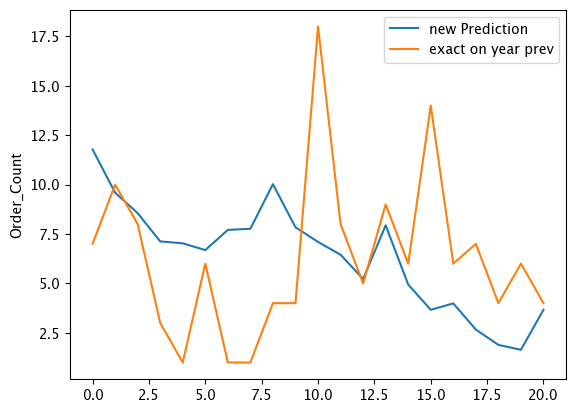

In [30]:
import pandas as pd
import seaborn as sns
pred_data = data_infer.iloc[-n_next:, :]['Order_Count']

prev_index = pred_data.index - pd.Timedelta(days=365)
prev_data = data_infer.reset_index()
start_prev_index = prev_data[prev_data['index'] == prev_index[0]].index[0]
end_prev_index = start_prev_index + n_next

prev_data = prev_data.iloc[start_prev_index:end_prev_index]

sns.lineplot(pred_data.reset_index()['Order_Count'], label='new Prediction')
sns.lineplot(prev_data.reset_index()['Order_Count'], label='exact on year prev')